In [ ]:
!pip install biopython
!pip install fair-esm biopython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from Bio import SeqIO

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)

CLASS_NAMES = [
    'Not Enzyme', 'Oxidoreductase', 'Transferase',
    'Hydrolase', 'Lyase', 'Isomerase', 'Ligase'
]


PyTorch: 2.10.0+cu128
GPU available: True


In [ ]:
def fasta_concat(filename, label):
    rows = []
    for record in SeqIO.parse(filename, 'fasta'):
        rows.append({'id': record.id, 'sequence': str(record.seq), 'label': label})
    return pd.DataFrame(rows)

# concatenate fasta files
files = [
    ('class0_rep_seq.fasta', 0),
    ('ec1_rep_seq.fasta',    1),
    ('ec2_rep_seq.fasta',    2),
    ('ec3_rep_seq.fasta',    3),
    ('ec4_rep_seq.fasta',    4),
    ('ec5_rep_seq.fasta',    5),
    ('ec6_rep_seq.fasta',    6),
]

df = pd.concat([fasta_concat(f, label) for f, label in files], ignore_index=True)
df['label'] = df['label'].astype(int)

# Sequence Cleaning
VALID_AA = set('ACDEFGHIKLMNPQRSTVWY')

def clean_seq(s):
    s = str(s).upper().strip().replace(' ', '').replace('\n', '')
    return re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', 'X', s)

df['sequence'] = df['sequence'].apply(clean_seq)
df['length']   = df['sequence'].str.len()
df = df[df['length'] > 0].reset_index(drop=True)

print(f'Total sequences: {len(df)}')
print('\nClass distribution:')
print(df['label'].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))
print(f'\nSequence length — mean: {df.length.mean():.0f}, median: {df.length.median():.0f}, max: {df.length.max()}')

Total sequences: 39678

Class distribution:
label
Not Enzyme        32324
Oxidoreductase     1184
Transferase        2769
Hydrolase          2108
Lyase               600
Isomerase           411
Ligase              282
Name: count, dtype: int64

Sequence length — mean: 381, median: 310, max: 1200


In [ ]:
df.head()

,id,sequence,label,length
0,sp|O07599|YHFA_BACSU,MMEVGILPVHVLYVFFIGAIILFMLLRKDTTFISLFGIFIISLWAS...,0,463
1,sp|P0ADX3|YHFA_ECO57,MQARVKWVEGLTFLGESASGHQILMDGNSGDKAPSPMEMVLMAAGG...,0,134
2,sp|O74751|YHFA_SCHPO,MLAEYLVHVGRVNVFLDPETKDIPKCVADLKFPLPLTLSRSTPINP...,0,332
3,sp|O07601|YHFC_BACSU,MVSQEAVVFLALSGAIAFLLPIGLIVWFKRKYGASLKVFFIGALTF...,0,258
4,sp|O07604|YHFF_BACSU,MKIYKLKSTFGWEGDDGLGEQLIQQILAGEKSATCAPKSLYSKDEL...,0,135


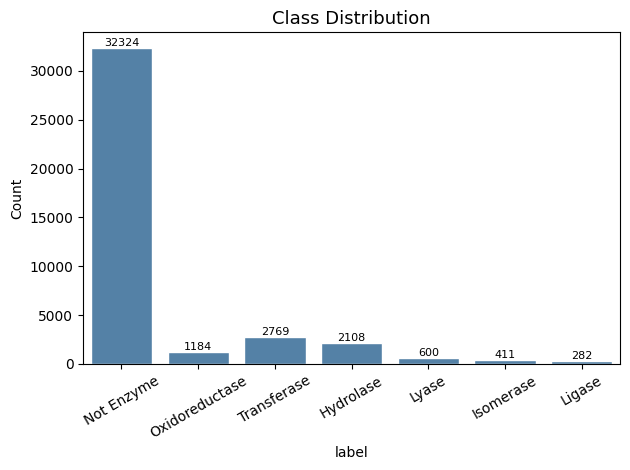

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['label'].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))).rename_axis('label').reset_index(name='count')
fig, ax = plt.subplots()
ax = sns.barplot(data=counts, x='label', y='count', color='steelblue', edgecolor='white')
ax.tick_params(axis='x', labelrotation=30)

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize = 8)
ax.set_title('Class Distribution', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

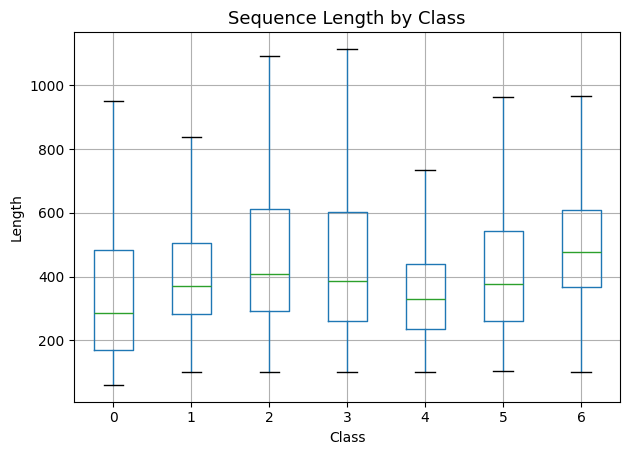

In [ ]:
df.boxplot(column='length', by='label', showfliers=False)
plt.title('Sequence Length by Class', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Length')
plt.suptitle('')
plt.tight_layout()
plt.savefig('sequence_length_by_class.png', dpi=150, bbox_inches='tight')

In [ ]:
import esm

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model.eval()

def embed_batch(seqs):
    data = [(str(i), s[:1022]) for i, s in enumerate(seqs)]
    _, _, batch_tokens = batch_converter(data)

    if torch.cuda.is_available():
      batch_tokens = batch_tokens.cuda()

    with torch.no_grad():
        results = esm_model(batch_tokens, repr_layers=[6])

    reps = results['representations'][6]
    embeddings = []
    for i, tok_len in enumerate((batch_tokens != alphabet.padding_idx).sum(1)):
        embeddings.append(reps[i, 1:tok_len - 1].mean(0).cpu().numpy())
    return embeddings

BATCH_SIZE = 32
all_seqs   = df['sequence'].tolist()
all_embeds = []

for i in range(0, len(all_seqs), BATCH_SIZE):
  batch = all_seqs[i:i + BATCH_SIZE]
  all_embeds.extend(embed_batch(batch))
  if i % 640 == 0:
     print(f'  {i:>6} / {len(all_seqs)} sequences embedded...')

  X_esm   = np.vstack(all_embeds)
  y_all   = df['label'].values
  seq_ids = df['id'].values


No saved embeddings found — computing now...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Using GPU
       0 / 39678 sequences embedded...
     640 / 39678 sequences embedded...
    1280 / 39678 sequences embedded...
    1920 / 39678 sequences embedded...
    2560 / 39678 sequences embedded...
    3200 / 39678 sequences embedded...
    3840 / 39678 sequences embedded...
    4480 / 39678 sequences embedded...
    5120 / 39678 sequences embedded...
    5760 / 39678 sequences embedded...
    6400 / 39678 sequences embedded...
    7040 / 39678 sequences embedded...
    7680 / 39678 sequences embedded...
    8320 / 39678 sequences embedded...
    8960 / 39678 sequences embedded...
    9600 / 39678 sequences embedded...

In [ ]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_esm, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print(f'Train: {X_train.shape[0]} sequences')
print(f'Test:  {X_test.shape[0]} sequences')
print('\nTrain class counts:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({CLASS_NAMES[u]}): {c}')

Train: 31742 sequences
Test:  7936 sequences

Train class counts:
  Class 0 (Not Enzyme): 25859
  Class 1 (Oxidoreductase): 947
  Class 2 (Transferase): 2215
  Class 3 (Hydrolase): 1686
  Class 4 (Lyase): 480
  Class 5 (Isomerase): 329
  Class 6 (Ligase): 226


In [ ]:
def evaluate(y_true, y_pred, model_name):
    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy:         {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Macro F1:         {f1_score(y_true, y_pred, average="macro"):.4f}')
    print(f'  Balanced Acc:     {balanced_accuracy_score(y_true, y_pred):.4f}')
    print(f'  MCC:              {matthews_corrcoef(y_true, y_pred):.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


In [ ]:
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import gc

try:
    del esm_model
    torch.cuda.empty_cache()
    gc.collect()
    print("GPU memory freed")
except:
    pass

# ── C tuning for Logistic Regression ─────────────────────────────────────────
print("Tuning C for Logistic Regression")
best_C, best_score = 1.0, 0.0

for C in [0.01, 0.1, 1.0, 10.0]:
    model_A = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced',
            C=C, solver='lbfgs', multi_class='multinomial', random_state=42
        ))
    ])
    scores = cross_val_score(
        model_A, X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='f1_macro'
    )
    print(f"  C={C:.3f}  Macro F1: {scores.mean():.4f} ± {scores.std():.4f}")
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_C = C

print(f"\nBest C: {best_C}  (Macro F1: {best_score:.4f})")

# Rebuild model_A using the best C
model_A = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000, class_weight='balanced',
        C=best_C, solver='lbfgs', multi_class='multinomial', random_state=42
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Model A: Logistic Regression + ESM
print("Model A: Logistic Regression + ESM")
y_cv_A = cross_val_predict(model_A, X_train, y_train, cv=cv)
evaluate(y_train, y_cv_A, 'Model A: Logistic Regression + ESM (CV)')

GPU memory freed
=== Tuning C for Logistic Regression ===
  C=0.010  Macro F1: 0.4134 ± 0.0114
  C=0.100  Macro F1: 0.4059 ± 0.0097
  C=1.000  Macro F1: 0.3970 ± 0.0131
  C=10.000  Macro F1: 0.3952 ± 0.0126

Best C: 0.01  (Macro F1: 0.4134)
=== Model A: Logistic Regression + ESM ===

  Model A: Logistic Regression + ESM (CV)
  Accuracy:         0.7215
  Macro F1:         0.4133
  Balanced Acc:     0.6037
  MCC:              0.4496

                precision    recall  f1-score   support

    Not Enzyme       0.97      0.75      0.85     25859
Oxidoreductase       0.39      0.65      0.49       947
   Transferase       0.47      0.61      0.53      2215
     Hydrolase       0.36      0.58      0.45      1686
         Lyase       0.12      0.50      0.19       480
     Isomerase       0.08      0.39      0.14       329
        Ligase       0.15      0.74      0.25       226

      accuracy                           0.72     31742
     macro avg       0.36      0.60      0.41     31742
  

In [ ]:
# Model XGB: XGBoost + ESM
print("\nModel XGB: XGBoost + ESM")

model_XGB = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cpu',
        random_state=42,
        n_jobs=-1
    ))
])

all_preds_xgb = np.zeros(len(y_train), dtype=int)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"  Fold {fold+1}/5...")
    fold_model = clone(model_XGB)
    sw = compute_sample_weight('balanced', y_train[tr_idx])
    fold_model.fit(X_train[tr_idx], y_train[tr_idx], clf__sample_weight=sw)
    all_preds_xgb[val_idx] = fold_model.predict(X_train[val_idx])

evaluate(y_train, all_preds_xgb, 'Model XGB: XGBoost + ESM (CV)')


=== Model XGB: XGBoost + ESM ===
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

  Model XGB: XGBoost + ESM (CV)
  Accuracy:         0.8368
  Macro F1:         0.5086
  Balanced Acc:     0.5246
  MCC:              0.5529

                precision    recall  f1-score   support

    Not Enzyme       0.95      0.90      0.92     25859
Oxidoreductase       0.51      0.63      0.56       947
   Transferase       0.49      0.67      0.57      2215
     Hydrolase       0.45      0.62      0.52      1686
         Lyase       0.23      0.24      0.23       480
     Isomerase       0.43      0.19      0.26       329
        Ligase       0.58      0.43      0.49       226

      accuracy                           0.84     31742
     macro avg       0.52      0.52      0.51     31742
  weighted avg       0.86      0.84      0.84     31742



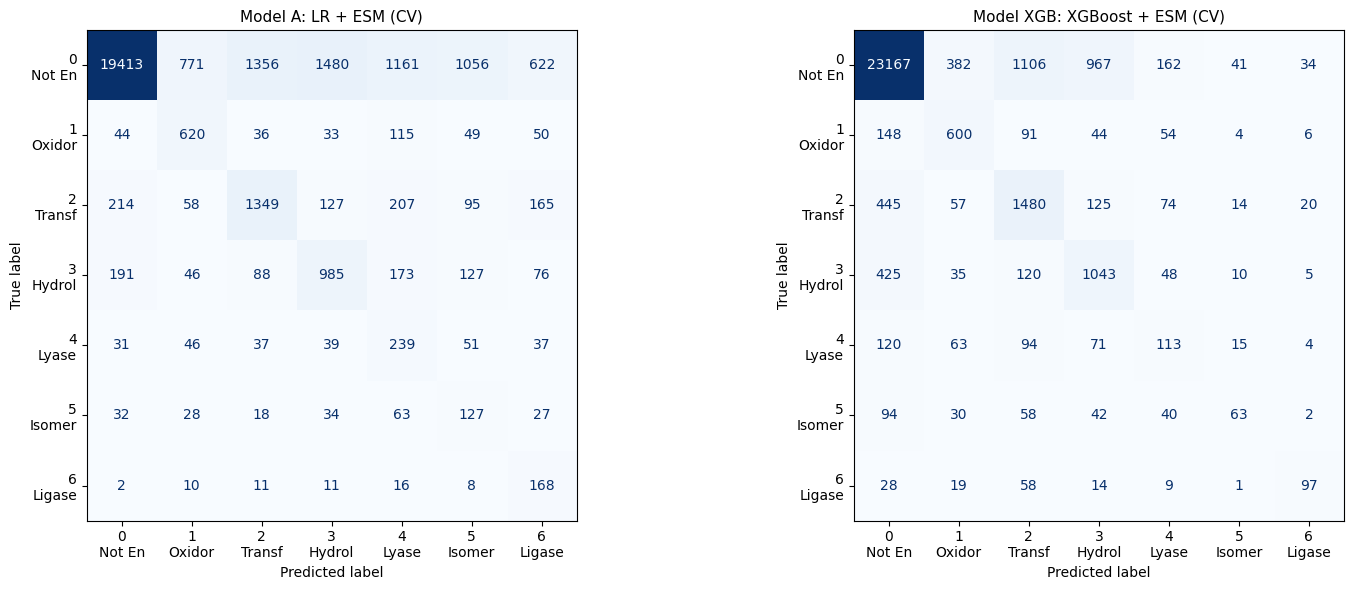

Saved to confusion_matrices_cv.png


In [ ]:
# Confusion matrices of both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_cv_A, all_preds_xgb],
    ['Model A: LR + ESM (CV)', 'Model XGB: XGBoost + ESM (CV)']
):
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_pred,
        display_labels=[f'{i}\n{n[:6]}' for i, n in enumerate(CLASS_NAMES)],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to confusion_matrices_cv.png')

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

print("Fitting Model A...")
model_A.fit(X_train, y_train)

print("Fitting Model XGB...")
sw = compute_sample_weight('balanced', y_train)
model_XGB.fit(X_train, y_train, clf__sample_weight=sw)

#Initialise the soft-voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr',  model_A),
        ('xgb', model_XGB)
    ],
    voting='soft',
    weights=[2, 1]
)

# Run CV
print("\nRunning 5-fold CV for Ensemble...")
all_preds_ens = np.zeros(len(y_train), dtype=int)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    print(f"  Fold {fold+1}/5...")
    fold_ens = clone(ensemble)
    sw_fold = compute_sample_weight('balanced', y_train[tr_idx])

    fold_ens.fit(X_train[tr_idx], y_train[tr_idx])
    all_preds_ens[val_idx] = fold_ens.predict(X_train[val_idx])

evaluate(y_train, all_preds_ens, 'Ensemble: LR + XGBoost (CV)')

Fitting Model A...
Fitting Model XGB...

Running 5-fold CV for Ensemble...
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...

  Ensemble: LR + XGBoost (CV)
  Accuracy:         0.8350
  Macro F1:         0.4949
  Balanced Acc:     0.5731
  MCC:              0.5445

                precision    recall  f1-score   support

    Not Enzyme       0.95      0.90      0.92     25859
Oxidoreductase       0.51      0.65      0.57       947
   Transferase       0.62      0.59      0.60      2215
     Hydrolase       0.50      0.55      0.53      1686
         Lyase       0.22      0.37      0.27       480
     Isomerase       0.18      0.29      0.22       329
        Ligase       0.24      0.67      0.35       226

      accuracy                           0.84     31742
     macro avg       0.46      0.57      0.49     31742
  weighted avg       0.86      0.84      0.85     31742




  Ensemble: LR + XGBoost
  Accuracy:         0.8328
  Macro F1:         0.4916
  Balanced Acc:     0.5846
  MCC:              0.5416

                precision    recall  f1-score   support

    Not Enzyme       0.94      0.89      0.92      6465
Oxidoreductase       0.51      0.61      0.56       237
   Transferase       0.63      0.62      0.63       554
     Hydrolase       0.50      0.53      0.51       422
         Lyase       0.20      0.36      0.25       120
     Isomerase       0.16      0.23      0.19        82
        Ligase       0.25      0.84      0.38        56

      accuracy                           0.83      7936
     macro avg       0.46      0.58      0.49      7936
  weighted avg       0.86      0.83      0.84      7936



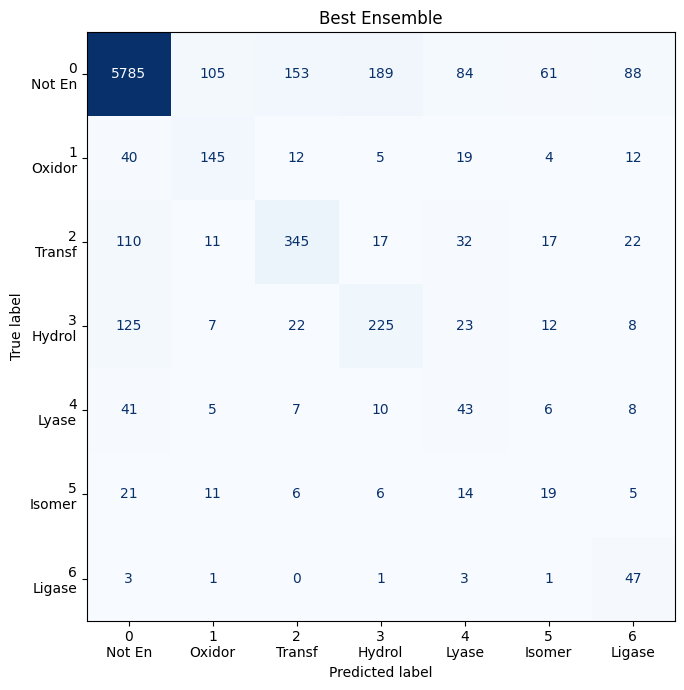

Saved confusion_matrix_test.png


In [ ]:
ensemble.fit(X_train, y_train)

y_best_predict = ensemble.predict(X_test)
evaluate(y_test, y_best_predict, 'Ensemble: LR + XGBoost')

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_best_predict,
    display_labels=[f'{i}\n{n[:6]}' for i, n in enumerate(CLASS_NAMES)],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Best Ensemble', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix_test.png')

In [ ]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

bio_props = []
for seq in df['sequence']:
    clean = seq.replace('X', 'A')
    pa = ProteinAnalysis(clean)
    bio_props.append({
            'isoelectric_point': pa.isoelectric_point(),
            'aromaticity':       pa.aromaticity(),
            'instability':       pa.instability_index(),
            'gravy':             pa.gravy(),
            'helix_fraction':    pa.secondary_structure_fraction()[0],
            'turn_fraction':     pa.secondary_structure_fraction()[1],
            'sheet_fraction':    pa.secondary_structure_fraction()[2],
            'mw':                pa.molecular_weight(),
            'length':            len(seq)
        })


bio_df = pd.DataFrame(bio_props)
#get coefficient from LR
coeffs = ensemble.named_estimators_['lr'].named_steps['clf'].coef_

correlations = {}
for prop in bio_df.columns:
    if bio_df[prop].isna().any():
        continue
    corr_vals = []
    for dim in range(X_esm.shape[1]):
        c = np.corrcoef(X_esm[:, dim], bio_df[prop])[0, 1]
        corr_vals.append(c)
    correlations[prop] = corr_vals

corr_df = pd.DataFrame(correlations, index=[f'ESM-{i}' for i in range(X_esm.shape[1])])

Computing correlations...


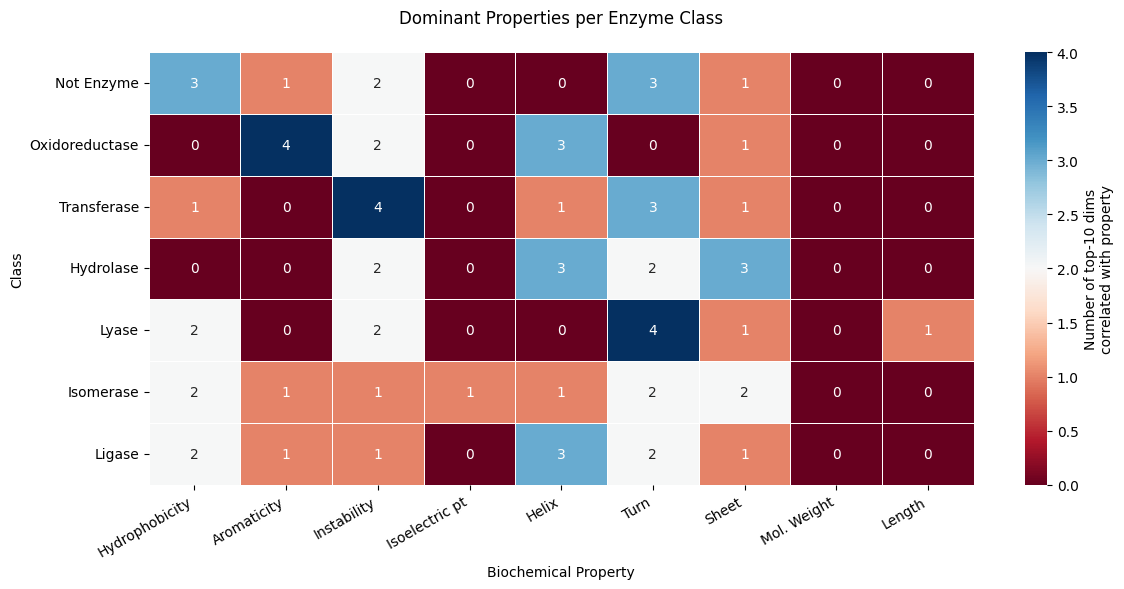

Saved biochemical_property_heatmap.png


In [ ]:
props = ['gravy', 'aromaticity', 'instability', 'isoelectric_point',
         'helix_fraction', 'turn_fraction', 'sheet_fraction', 'mw', 'length']

freq_matrix = np.zeros((len(CLASS_NAMES), len(props)))
fig_size = (12, 6)

for cls in range(len(CLASS_NAMES)):
    #choose top 10
    top_dims = np.argsort(np.abs(coeffs[cls]))[-10:][::-1]
    for dim in top_dims:
        best_prop = corr_df.loc[f'ESM-{dim}'].abs().idxmax()
        if best_prop in props:
            freq_matrix[cls, props.index(best_prop)] += 1

final_df = pd.DataFrame(
    freq_matrix,
    index=CLASS_NAMES,
    columns=['Hydrophobicity', 'Aromaticity', 'Instability',
             'Isoelectric pt', 'Helix', 'Turn', 'Sheet', 'Mol. Weight', 'Length']
)

plt.figure(figsize=fig_size)
sns.heatmap(
    final_df,
    annot=True,
    cmap='RdBu',
    linewidths=0.4,
    cbar_kws={'label': 'Number of top-10 dims\ncorrelated with property'}
)
plt.title('Dominant Properties per Enzyme Class\n', fontsize=12)
plt.xlabel('Biochemical Property')
plt.ylabel('Class')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('biochemical_property_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved biochemical_property_heatmap.png')

In [ ]:
proba = ensemble.predict_proba(X_test)
conf_scores = proba.max(axis=1)

def conf (p):
  if p >= 0.8 :
    return 'High'
  elif p >= 0.5 :
    return 'Medium'
  else :
    return 'Low'

confidences = [conf(p) for p in conf_scores]
print('Confidence: ')
for c in sorted(set(confidences)):
  print(f'  {c}: {confidences.count(c)}')

print('Accuracy by confidence level:')
for level in ['High', 'Medium', 'Low']:
    mask = np.array(confidences) == level
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_best_predict[mask])
        print(f'  {level}: n={mask.sum()}, accuracy={acc:.3f}')

Confidence: 
  High: 3312
  Low: 1815
  Medium: 2809
Accuracy by confidence level:
  High: n=3312, accuracy=0.974
  Medium: n=2809, accuracy=0.844
  Low: n=1815, accuracy=0.557


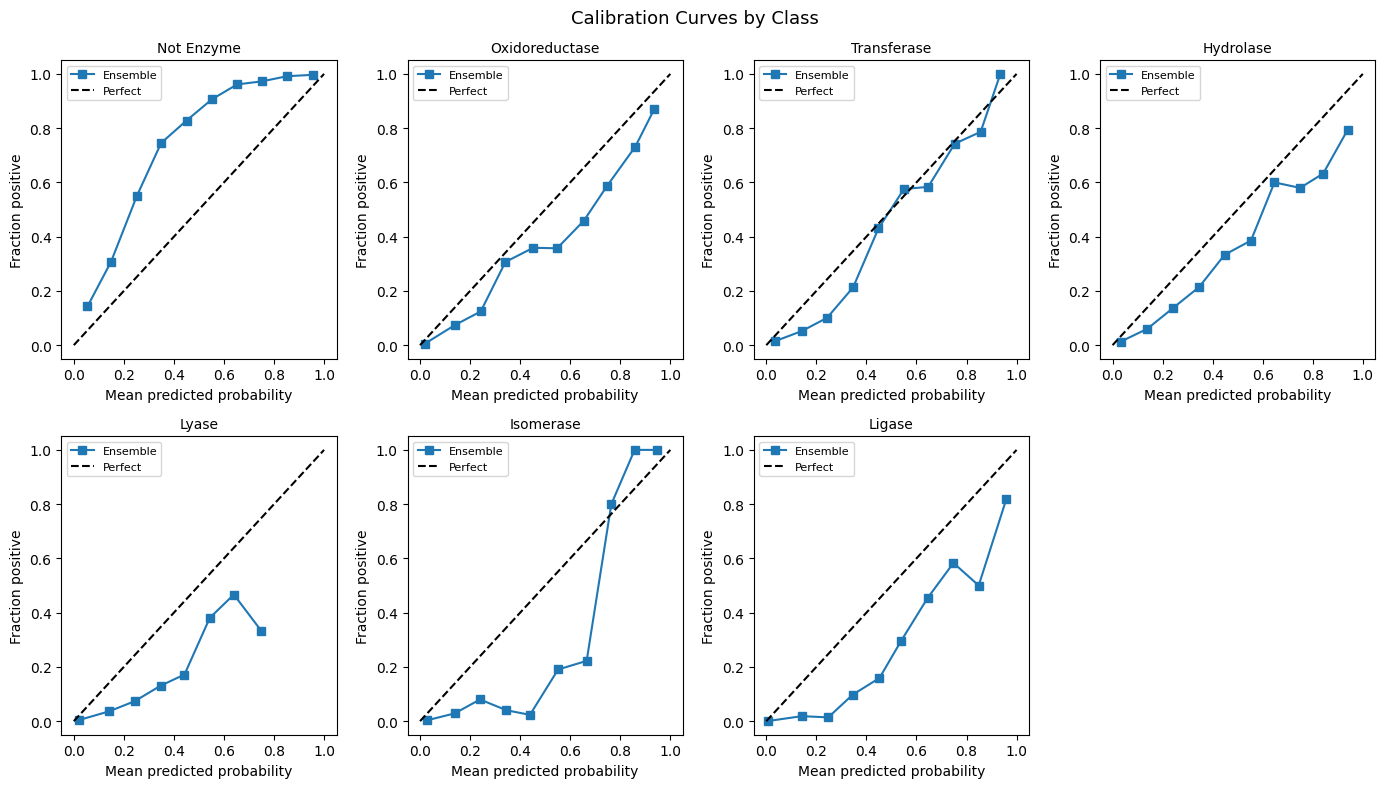

Saved calibration_curves.png


In [ ]:
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASS_NAMES))))

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i in range(len(CLASS_NAMES)):
    frac_pos, mean_pred = calibration_curve(y_test_bin[:, i], proba[:, i], n_bins=10)
    axes[i].plot(mean_pred, frac_pos, 's-', label='Ensemble')
    axes[i].plot([0,1],[0,1],'k--', label='Perfect')
    axes[i].set_title(CLASS_NAMES[i], fontsize=10)
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction positive')
    axes[i].legend(fontsize=8)

axes[7].axis('off')
plt.suptitle('Calibration Curves by Class', fontsize=13)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved calibration_curves.png')

In [ ]:
BLIND_FASTA = 'blind_ec_test.fasta'

import esm as esm_module
esm_model2, alphabet2 = esm_module.pretrained.esm2_t6_8M_UR50D()
batch_converter2 = alphabet2.get_batch_converter()
esm_model2.eval()
if torch.cuda.is_available():
    esm_model2 = esm_model2.cuda()

def embed_batch_blind(seqs):
    data = [(str(i), s[:1022]) for i, s in enumerate(seqs)]
    _, _, batch_tokens = batch_converter2(data)
    if torch.cuda.is_available():
        batch_tokens = batch_tokens.cuda()
    with torch.no_grad():
        results = esm_model2(batch_tokens, repr_layers=[6])
    reps = results['representations'][6]
    embs = []
    for i, tok_len in enumerate((batch_tokens != alphabet2.padding_idx).sum(1)):
        embs.append(reps[i, 1:tok_len-1].mean(0).cpu().numpy())
    return embs

blind_records = list(SeqIO.parse(BLIND_FASTA, 'fasta'))
blind_ids  = [r.id for r in blind_records]
blind_seqs = [clean_seq(str(r.seq)) for r in blind_records]

blind_embeds = []
for i in range(0, len(blind_seqs), 32):
    blind_embeds.extend(embed_batch_blind(blind_seqs[i:i+32]))
    if i % 320 == 0:
        print(f'  {i} / {len(blind_seqs)}')
X_blind = np.vstack(blind_embeds)

blind_proba  = ensemble.predict_proba(X_blind)
blind_preds  = blind_proba.argmax(axis=1)
blind_conf   = blind_proba.max(axis=1)
blind_levels = [conf(p) for p in blind_conf]     # ← conf not confidences

with open('predictions.txt', 'w') as f:
    for sid, pred, level in zip(blind_ids, blind_preds, blind_levels):
        f.write(f'{sid} {pred} Confidence {level}\n')

print(f'Written {len(blind_ids)} predictions to predictions.txt')
print('\nFirst 5 lines:')
with open('predictions.txt') as f:
    for line in list(f)[:5]:
        print(' ', line.strip())

  0 / 22
Written 22 predictions to predictions.txt

First 5 lines:
  SEQ01 2 Confidence Medium
  SEQ02 3 Confidence Low
  SEQ03 3 Confidence Medium
  SEQ04 1 Confidence Medium
  SEQ05 3 Confidence High
